[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Dragomier/Machine_Learning_2026/blob/main/Homework5.ipynb)

# First question
We recreate our circular data, transform it into 3D space using $\phi$ function from a class and try to understand why preimage of a decision boundary in 2D is circular.

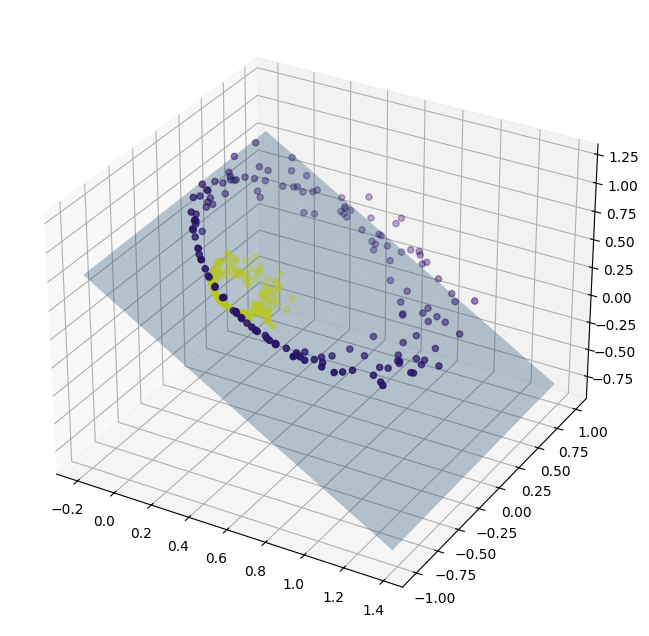

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles

# We create circles and color them, depending on a class
np.random.seed(0)
X, y = make_circles(n_samples=300, factor=0.5, noise=0.05)
y = np.where(y == 0, -1, 1)
colors = np.where(y == -1, "#330066", "yellow")

# We embed our data into 3d space, according to phi function. Then we perform SVC
lifted_data = np.c_[X[:, 0]*X[:, 0], np.sqrt(2)*X[:, 0]*X[:, 1], X[:, 1]* X[:, 1]]
clf = SVC(kernel='linear', C=1e2)
clf.fit(lifted_data, y)

# We plot our data points and separating hyperplane
margin = 0.2
hyperplane_coef = clf.coef_[0]
hyperplane_intercept = clf.intercept_[0]

x_data = np.arange(lifted_data[:, 0].min() - margin, lifted_data[:, 0].max() + margin, 0.01)
y_data = np.arange(lifted_data[:, 1].min() - margin, lifted_data[:, 1].max() + margin, 0.01)

X_plot, Y_plot = np.meshgrid(x_data, y_data)
Z_plot = -1*(hyperplane_intercept + hyperplane_coef[0]*X_plot + hyperplane_coef[1]*Y_plot)/(hyperplane_coef[2])

%matplotlib notebook
%matplotlib inline
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(lifted_data[:, 0], lifted_data[:, 1], lifted_data[:, 2], c=colors)
ax.plot_surface(X_plot, Y_plot, Z_plot, alpha = 0.3)

plt.show()

We observe that when we lifted our data into 3-dimensional space, it became separable, so SVC could find a separating hyperplane, which has 100% accuracy in separating our data. Now we try to understand, what is the preimage of this hyperplane by our $\phi$ function. In order to do that we create a grid and finds points, to which our SVC give the *zero* class.

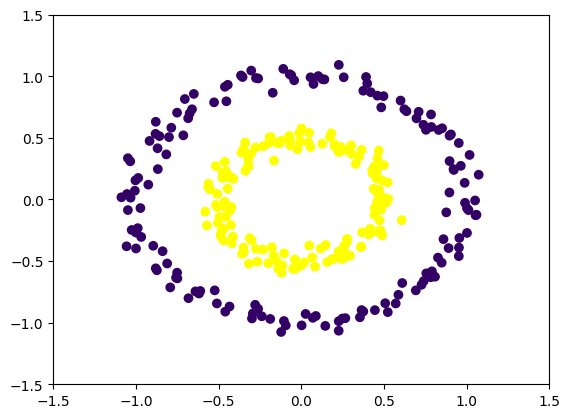

In [5]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 500), np.linspace(-1.5, 1.5, 500))

x_flat = xx.ravel()
y_flat = yy.ravel()

Z = clf.decision_function(np.c_[x_flat*x_flat, np.sqrt(2)*x_flat*y_flat, y_flat*y_flat])
Z = Z.reshape(xx.shape)

plt.figure()
plt.contour(xx, yy, Z, levels=[0], colors='white')
plt.scatter(X[:, 0], X[:, 1], c=colors)
plt.show()

# Conclusion
We see that decision boundary is not linear, because after using $\phi$ function coordinates are no longer linear, but in our case they become quadratic. SVM algorithm finds a linear equation between these coordinates, but since the coordinates are no longer linear in the domain, then the equation in the domain also is not linear. That is the reason why our separating hyperplane in 2D does not look 'flat'.

# Second question
Take a point $P(x,y)$, that lies in the separating hyperplane. Then $\phi(P) = (x^2, \sqrt{2}xy, y^2)$.

Suppose that a hyperplane $H$, which contains $P$, has an equation $w_1x_1 + w_2x_2 + w_3x_3 + b = 0$.
Substituting coordinates of $\phi(P)$ to the equation of our hyperplane we obtain:
$$w_1x^2 + w_2\sqrt{2}xy + w_3y^2 + b = 0$$
It is a general equation of a conic section. Moreover, we observe that the separating hyperplane is bounded by two circles, so our decision boundary must also be bounded and the only bounded conic section is an elipse (or its special case - circle).